<a href="https://colab.research.google.com/github/rohanbhangale/mldl_exps/blob/main/Mldl_exp_05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Preview:
   age         job  marital  education default  balance housing loan  contact  \
0   59      admin.  married  secondary      no     2343     yes   no  unknown   
1   56      admin.  married  secondary      no       45      no   no  unknown   
2   41  technician  married  secondary      no     1270     yes   no  unknown   
3   55    services  married  secondary      no     2476     yes   no  unknown   
4   54      admin.  married   tertiary      no      184      no   no  unknown   

   day month  duration  campaign  pdays  previous poutcome deposit  
0    5   may      1042         1     -1         0  unknown     yes  
1    5   may      1467         1     -1         0  unknown     yes  
2    5   may      1389         1     -1         0  unknown     yes  
3    5   may       579         1     -1         0  unknown     yes  
4    5   may       673         2     -1         0  unknown     yes  

SVM (Before Tuning):
Accuracy: 0.8132557098074339
Fitting 5 folds for each of 12 

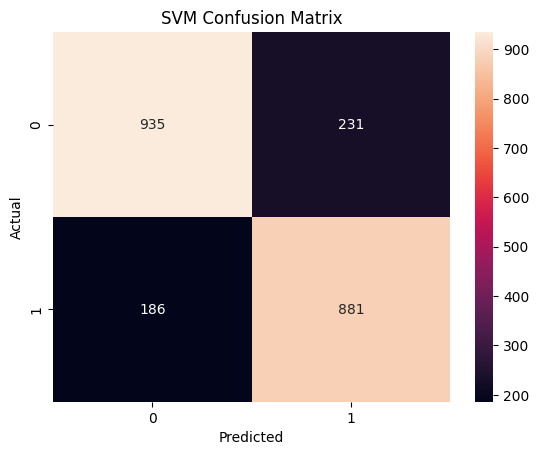

In [ ]:
# ===============================
# 1. Import Libraries
# ===============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ===============================
# 2. Load Dataset
# ===============================
url = "/content/bank.csv"

df = pd.read_csv(url, sep=',') # Changed separator from ';' to ','

print("Dataset Preview:")
print(df.head())

# ===============================
# 3. Data Preprocessing
# ===============================

# Encode categorical columns
le = LabelEncoder()

# Exclude 'deposit' (target variable) from encoding if it's categorical and will be handled separately
# Or ensure it's encoded if it's categorical. Assuming 'deposit' is the target and will be encoded.
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

# Features & Target
X = df.drop('deposit', axis=1) # Changed target column from 'y' to 'deposit'
y = df['deposit'] # Changed target column from 'y' to 'deposit'

# ===============================
# 4. Train-Test Split
# ===============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ===============================
# 5. Feature Scaling (IMPORTANT for SVM)
# ===============================
scaler = StandardScaler() # Fixed typo: 'schaler' to 'scaler'

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ===============================
# 6. SVM Model (Before Tuning)
# ===============================
svm = SVC()

svm.fit(X_train, y_train)
y_pred = svm.predict(X_test)

print("\nSVM (Before Tuning):")
print("Accuracy:", accuracy_score(y_test, y_pred))

# ===============================
# 7. Hyperparameter Tuning (GridSearchCV)
# ===============================
param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

grid = GridSearchCV(SVC(), param_grid, cv=5, verbose=1, n_jobs=-1)
grid.fit(X_train, y_train)

print("\nBest Parameters:", grid.best_params_)

# ===============================
# 8. Best Model
# ===============================
best_svm = grid.best_estimator_

y_pred_best = best_svm.predict(X_test)

print("\nSVM (After Tuning):")
print("Accuracy:", accuracy_score(y_test, y_pred_best))
print("\nClassification Report:\n", classification_report(y_test, y_pred_best))

# ===============================
# 9. Confusion Matrix
# ===============================
plt.figure()
sns.heatmap(confusion_matrix(y_test, y_pred_best), annot=True, fmt='d')
plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()